In [24]:
!pip install mplsoccer

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import PyPizza, add_image, FontManager

from scipy import stats
import math

In [26]:
df = pd.read_csv('/content/drive/MyDrive/F_Data_Academy/pizza_tutorial.csv')

df['Player'] = df['Player'].str.split('\\',expand=True)[0]

In [27]:
df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Tackles,Tkls Won,...,Dribbled Past,Successful Pressures,Def 3rd Press,Mid 3rd Press,Att 3rd Press,Blocks,Interceptions,Tkl+Int,Clearances,Errors
0,1,Patrick van Aanholt,nl NED,DF,Crystal Palace,30-259,1990,19.7,1.62,0.96,...,1.37,3.45,6.55,2.84,1.02,1.57,1.73,3.35,2.03,0.05
1,2,Tammy Abraham,eng ENG,FW,Chelsea,23-225,1997,11.6,0.69,0.34,...,0.43,3.28,1.12,6.12,6.72,0.78,0.17,0.86,1.47,0.00
2,3,Che Adams,sco SCO,FW,Southampton,24-306,1996,28.1,1.03,0.57,...,0.57,4.70,1.71,5.41,7.12,0.89,0.36,1.39,0.57,0.04
3,4,Tosin Adarabioyo,eng ENG,DF,Fulham,23-233,1997,29.8,1.28,0.77,...,0.54,1.78,3.66,1.64,0.23,1.17,1.68,2.95,7.38,0.03
4,5,Adrián,es ESP,GK,Liverpool,34-132,1987,3.0,0.00,0.00,...,0.00,0.00,0.33,0.00,0.00,0.00,0.00,0.00,0.00,0.33


In [28]:
df = df.loc[(df['Pos'] == 'DF') & (df['90s']>15)]
df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Tackles,Tkls Won,...,Dribbled Past,Successful Pressures,Def 3rd Press,Mid 3rd Press,Att 3rd Press,Blocks,Interceptions,Tkl+Int,Clearances,Errors
0,1,Patrick van Aanholt,nl NED,DF,Crystal Palace,30-259,1990,19.7,1.62,0.96,...,1.37,3.45,6.55,2.84,1.02,1.57,1.73,3.35,2.03,0.05
3,4,Tosin Adarabioyo,eng ENG,DF,Fulham,23-233,1997,29.8,1.28,0.77,...,0.54,1.78,3.66,1.64,0.23,1.17,1.68,2.95,7.38,0.03
6,7,Ola Aina,ng NGA,DF,Fulham,24-219,1996,28.9,1.63,0.87,...,0.80,2.11,4.74,3.11,0.76,1.56,1.76,3.39,4.19,0.00
8,9,Semi Ajayi,ng NGA,DF,West Brom,27-187,1993,27.9,2.04,1.47,...,0.54,4.48,7.46,3.33,0.57,1.90,1.25,3.30,4.70,0.07
12,13,Toby Alderweireld,be BEL,DF,Tottenham,32-074,1989,21.9,1.55,0.73,...,0.50,2.97,5.16,3.06,0.14,1.96,0.46,2.01,6.80,0.00


In [29]:
df = df.drop(['Rk', 'Nation', 'Pos', 'Squad', 'Age', 'Born'],axis=1).reset_index()

In [30]:
df.head()

,index,Player,90s,Tackles,Tkls Won,Tkls vs Dribbles,Dribbled Past,Successful Pressures,Def 3rd Press,Mid 3rd Press,Att 3rd Press,Blocks,Interceptions,Tkl+Int,Clearances,Errors
0,0,Patrick van Aanholt,19.7,1.62,0.96,0.71,1.37,3.45,6.55,2.84,1.02,1.57,1.73,3.35,2.03,0.05
1,3,Tosin Adarabioyo,29.8,1.28,0.77,0.57,0.54,1.78,3.66,1.64,0.23,1.17,1.68,2.95,7.38,0.03
2,6,Ola Aina,28.9,1.63,0.87,0.59,0.80,2.11,4.74,3.11,0.76,1.56,1.76,3.39,4.19,0.00
3,8,Semi Ajayi,27.9,2.04,1.47,0.65,0.54,4.48,7.46,3.33,0.57,1.90,1.25,3.30,4.70,0.07
4,12,Toby Alderweireld,21.9,1.55,0.73,0.59,0.50,2.97,5.16,3.06,0.14,1.96,0.46,2.01,6.80,0.00


In [31]:
params = list(df.columns)
params

['index',
 'Player',
 '90s',
 'Tackles',
 'Tkls Won',
 'Tkls vs Dribbles',
 'Dribbled Past',
 'Successful Pressures',
 'Def 3rd Press',
 'Mid 3rd Press',
 'Att 3rd Press',
 'Blocks',
 'Interceptions',
 'Tkl+Int',
 'Clearances',
 'Errors']

In [32]:
params = params[2:]
params

['90s',
 'Tackles',
 'Tkls Won',
 'Tkls vs Dribbles',
 'Dribbled Past',
 'Successful Pressures',
 'Def 3rd Press',
 'Mid 3rd Press',
 'Att 3rd Press',
 'Blocks',
 'Interceptions',
 'Tkl+Int',
 'Clearances',
 'Errors']

In [33]:
conteo_jugadores = df['Player'].value_counts()

print("LISTA COMPLETA DE JUGADORES Y SUS EVENTOS:")
print("==========================================")
for jugador, total in conteo_jugadores.items():
    print(f"- {jugador}: {total} eventos")

LISTA COMPLETA DE JUGADORES Y SUS EVENTOS:
- Patrick van Aanholt: 1 eventos
- Tosin Adarabioyo: 1 eventos
- Ola Aina: 1 eventos
- Semi Ajayi: 1 eventos
- Toby Alderweireld: 1 eventos
- Trent Alexander-Arnold: 1 eventos
- Ezgjan Alioski: 1 eventos
- Joachim Andersen: 1 eventos
- Serge Aurier: 1 eventos
- Luke Ayling: 1 eventos
- César Azpilicueta: 1 eventos
- George Baldock: 1 eventos
- Kyle Bartley: 1 eventos
- Jan Bednarek: 1 eventos
- Héctor Bellerín: 1 eventos
- Ryan Bertrand: 1 eventos
- Willy Boly: 1 eventos
- Dan Burn: 1 eventos
- Gary Cahill: 1 eventos
- João Cancelo: 1 eventos
- Matty Cash: 1 eventos
- Timothy Castagne: 1 eventos
- Ben Chilwell: 1 eventos
- Andreas Christensen: 1 eventos
- Ciaran Clark: 1 eventos
- Conor Coady: 1 eventos
- Séamus Coleman: 1 eventos
- Liam Cooper: 1 eventos
- Vladimír Coufal: 1 eventos
- Aaron Cresswell: 1 eventos
- Craig Dawson: 1 eventos
- Rúben Dias: 1 eventos
- Eric Dier: 1 eventos
- Lucas Digne: 1 eventos
- Issa Diop: 1 eventos
- Gabriel Do

In [34]:
player = df.loc[df['Player'] == 'Nélson Semedo'].reset_index()
player = list(player.loc[0])
print(player)

[np.int64(69), np.int64(422), 'Nélson Semedo', np.float64(30.1), np.float64(2.62), np.float64(1.63), np.float64(1.2), np.float64(0.93), np.float64(4.82), np.float64(8.14), np.float64(5.35), np.float64(2.79), np.float64(1.76), np.float64(1.36), np.float64(3.99), np.float64(2.76), np.float64(0.0)]


In [35]:
info_jugador = df.loc[df['Player'] == 'Nélson Semedo'].reset_index(drop=True).loc[0]

print(info_jugador)

index                             422
Player                  Nélson Semedo
90s                              30.1
Tackles                          2.62
Tkls Won                         1.63
Tkls vs Dribbles                  1.2
Dribbled Past                    0.93
Successful Pressures             4.82
Def 3rd Press                    8.14
Mid 3rd Press                    5.35
Att 3rd Press                    2.79
Blocks                           1.76
Interceptions                    1.36
Tkl+Int                          3.99
Clearances                       2.76
Errors                            0.0
Name: 0, dtype: object


In [36]:
df.Player.values

array(['Patrick van Aanholt', 'Tosin Adarabioyo', 'Ola Aina',
       'Semi Ajayi', 'Toby Alderweireld', 'Trent Alexander-Arnold',
       'Ezgjan Alioski', 'Joachim Andersen', 'Serge Aurier',
       'Luke Ayling', 'César Azpilicueta', 'George Baldock',
       'Kyle Bartley', 'Jan Bednarek', 'Héctor Bellerín', 'Ryan Bertrand',
       'Willy Boly', 'Dan Burn', 'Gary Cahill', 'João Cancelo',
       'Matty Cash', 'Timothy Castagne', 'Ben Chilwell',
       'Andreas Christensen', 'Ciaran Clark', 'Conor Coady',
       'Séamus Coleman', 'Liam Cooper', 'Vladimír Coufal',
       'Aaron Cresswell', 'Craig Dawson', 'Rúben Dias', 'Eric Dier',
       'Lucas Digne', 'Issa Diop', 'Gabriel Dos Santos', 'Lewis Dunk',
       'John Egan', 'Jonny Evans', 'Federico Fernández', 'Wesley Fofana',
       'Darnell Furlong', 'Ben Godfrey', 'Rob Holding', 'Mason Holgate',
       'Reece James', 'James Justin', 'Michael Keane', 'Ezri Konsa',
       'Cheikhou Kouyaté', 'Jamaal Lascelles', 'Jamal Lewis',
       'Victor

In [37]:
print(len(player),print(len(params)))
player = player[3:]
print(len(player),print(len(params)))

14
17 None
14
14 None


In [38]:
values = []
for x in range(len(params)):
  values.append(math.floor(stats.percentileofscore(df[params[x]],player[x])))

In [39]:
round(stats.percentileofscore(df[params[0]],player[0]))

81

In [40]:
for n,i in enumerate(values):
  if i == 100:
    values[n] = 99

In [41]:
baker = PyPizza(
    params=params,
    straight_line_color="#000000",
    straight_line_lw=1,
    last_circle_lw=1,
    other_circle_lw=1,
    other_circle_ls="-."
)

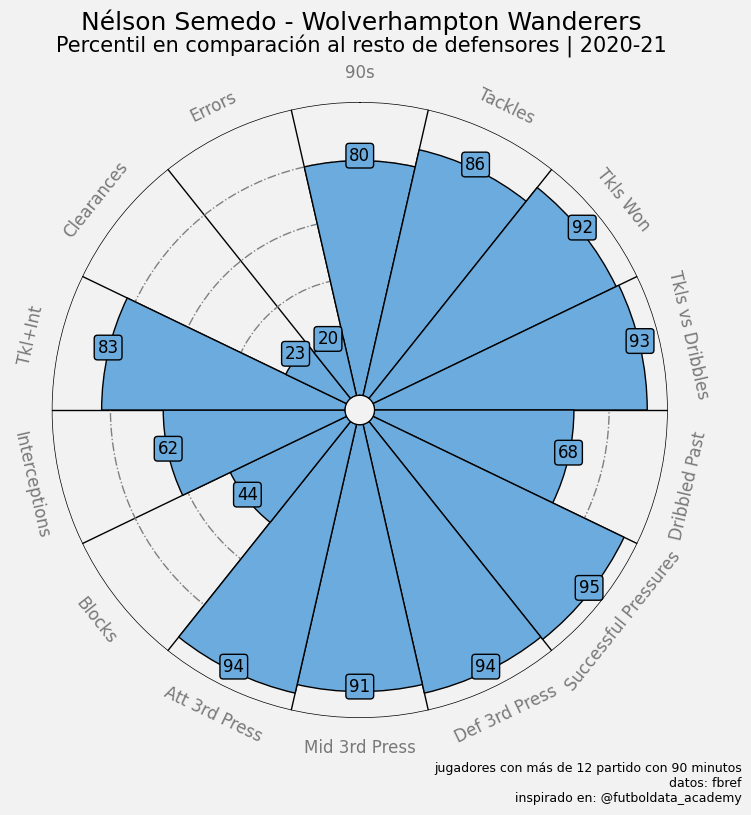

In [42]:
fig, ax = baker.make_pizza(
 values,
 figsize=(8, 8),
 param_location=110,
 kwargs_slices=dict(
 facecolor="#6CABDD", edgecolor="#000000",
 zorder=2, linewidth=1
 ),
 kwargs_params=dict(
 color="#000000", fontsize=12,
 va="center", alpha=.5
 ),
 kwargs_values=dict(
 color="#000000", fontsize=12,
 zorder=3,
 bbox=dict(
 edgecolor="#000000", facecolor="#6CABDD",
 boxstyle="round,pad=0.2", lw=1
 )
 )
)
# Título del radar
fig.text(
 0.515, 0.97, "Nélson Semedo - Wolverhampton Wanderers", size=18,
 ha="center", color="#000000"
)
# Subtítulo del radar
fig.text(
 0.515, 0.942,
 "Percentil en comparación al resto de defensores | 2020-21",
 size=15,
 ha="center", color="#000000"
)
# añade créditos
notes = 'jugadores con más de 12 partido con 90 minutos'
CREDIT_1 = "datos: fbref"
CREDIT_2 = "inspirado en: @futboldata_academy"
fig.text(
 0.99, 0.005, f"{notes}\n{CREDIT_1}\n{CREDIT_2}", size=9,
 color="#000000",
 ha="right"
)
plt.savefig('pizza.png',dpi=500,bbox_inches = 'tight')